### Importação dos dados



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [ ]:
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

In [ ]:
df_lojas = pd.concat([loja, loja2, loja3, loja4])
df_lojas.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [ ]:
df_lojas['Loja'].unique()

array(['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4'], dtype=object)

In [ ]:
faturamento = df_lojas.groupby('Loja')[['Preço']].sum().sort_values(by='Preço', ascending=True).rename(columns={'Preço': 'Faturamento'})
faturamento

,Faturamento
Loja,
Loja 4,1384497.58
Loja 3,1464025.03
Loja 2,1488459.06
Loja 1,1534509.12


# 2. Vendas por Categoria

In [ ]:
df_lojas['Categoria do Produto'].unique()

array(['eletronicos', 'moveis', 'brinquedos', 'eletrodomesticos',
       'utilidades domesticas', 'esporte e lazer', 'livros',
       'instrumentos musicais'], dtype=object)

In [ ]:
vendas_por_categorias = df_lojas.groupby('Loja')['Categoria do Produto'].value_counts().unstack()
vendas_por_categorias

Categoria do Produto,brinquedos,eletrodomesticos,eletronicos,esporte e lazer,instrumentos musicais,livros,moveis,utilidades domesticas
Loja,,,,,,,,
Loja 1,324,312,448,284,182,173,465,171
Loja 2,313,305,422,275,224,197,442,181
Loja 3,315,278,451,277,177,185,499,177
Loja 4,338,254,451,277,170,187,480,201


# 3. Média de Avaliação das Lojas


In [ ]:
media_avaliacao = df_lojas.groupby('Loja')['Avaliação da compra'].mean().sort_values(ascending=False)
media_avaliacao

,Avaliação da compra
Loja,
Loja 3,4.048326
Loja 2,4.037304
Loja 4,3.995759
Loja 1,3.976685


# 4. Produtos Mais e Menos Vendidos

In [ ]:
vendas_produtos = df_lojas.groupby('Loja')['Produto'].value_counts()
vendas = vendas_produtos.reset_index(name='Quantidade')
vendas

,Loja,Produto,Quantidade
0,Loja 1,Guarda roupas,60
1,Loja 1,Micro-ondas,60
2,Loja 1,TV Led UHD 4K,60
3,Loja 1,Secadora de roupas,58
4,Loja 1,Blocos de montar,56
...,...,...,...
199,Loja 4,Geladeira,38
200,Loja 4,Lavadora de roupas,38
201,Loja 4,Violão,37
202,Loja 4,Guarda roupas,34


In [ ]:
mais = vendas.loc[vendas.groupby('Loja')['Quantidade'].idxmax()]
mais

,Loja,Produto,Quantidade
0,Loja 1,Guarda roupas,60
51,Loja 2,Iniciando em programação,65
102,Loja 3,Kit banquetas,57
153,Loja 4,Cama box,62


In [ ]:
menos = vendas.loc[vendas.groupby('Loja')['Quantidade'].idxmin()]
menos

,Loja,Produto,Quantidade
49,Loja 1,Celular ABXY,33
101,Loja 2,Jogo de tabuleiro,32
152,Loja 3,Blocos de montar,35
203,Loja 4,Guitarra,33


In [ ]:
resutado_vendas = mais[['Loja', 'Produto', 'Quantidade']].rename(columns={'Produto': 'Produto Mais Vendido', 'Quantidade': 'Quantidade Mais Vendido'}).merge(menos[['Loja', 'Produto', 'Quantidade']].rename(columns={'Produto': 'Produto Menos Vendido', 'Quantidade': 'Quantidade menos Vendido'}))
resutado_vendas

,Loja,Produto Mais Vendido,Quantidade Mais Vendido,Produto Menos Vendido,Quantidade menos Vendido
0,Loja 1,Guarda roupas,60,Celular ABXY,33
1,Loja 2,Iniciando em programação,65,Jogo de tabuleiro,32
2,Loja 3,Kit banquetas,57,Blocos de montar,35
3,Loja 4,Cama box,62,Guitarra,33


In [ ]:
resutado_vendas.set_index('Loja', inplace=True)
resutado_vendas

,Produto Mais Vendido,Quantidade Mais Vendido,Produto Menos Vendido,Quantidade menos Vendido
Loja,,,,
Loja 1,Guarda roupas,60,Celular ABXY,33
Loja 2,Iniciando em programação,65,Jogo de tabuleiro,32
Loja 3,Kit banquetas,57,Blocos de montar,35
Loja 4,Cama box,62,Guitarra,33


# 5. Frete Médio por Loja

In [ ]:
frete_medio = df_lojas.groupby('Loja')['Frete'].mean()
frete_medio

,Frete
Loja,
Loja 1,34.691805
Loja 2,33.621941
Loja 3,33.074464
Loja 4,31.278997


# Gráficos

Faturamento

<Axes: ylabel='Loja'>

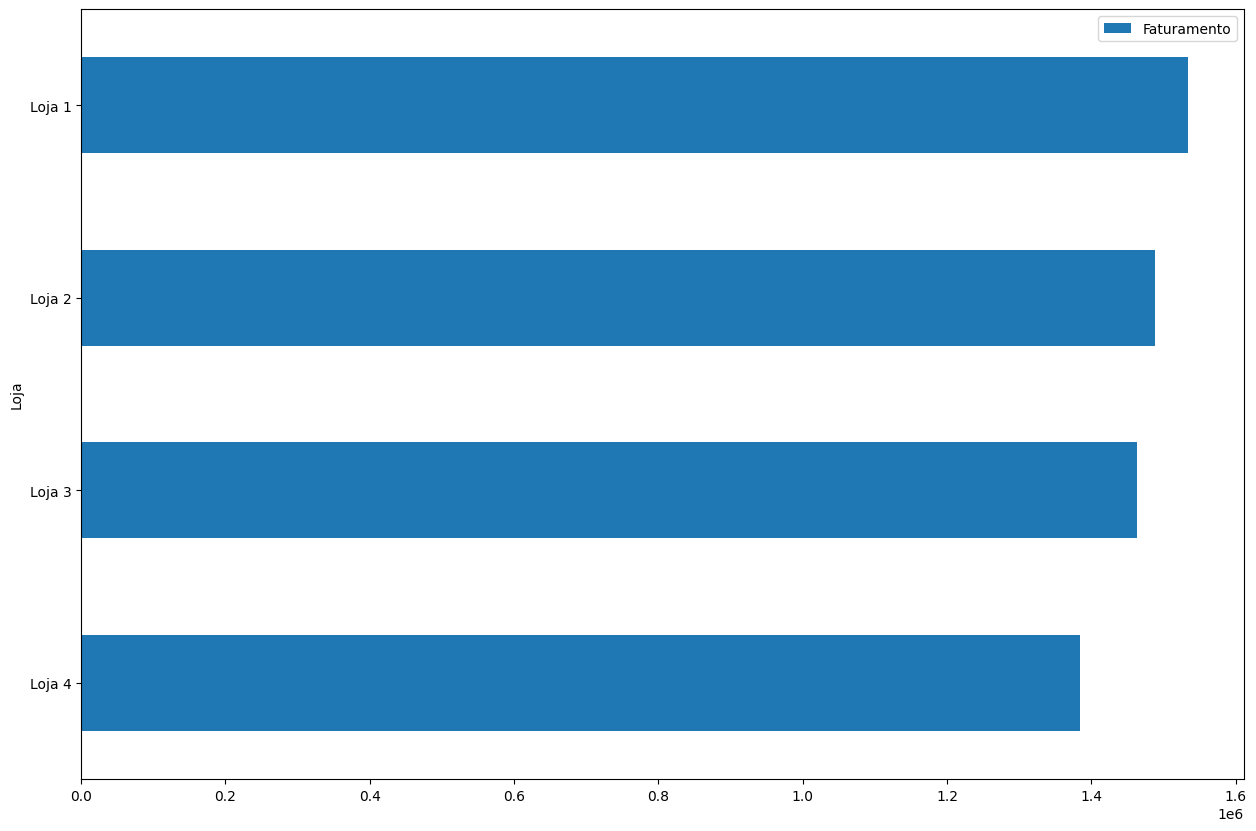

In [ ]:
faturamento.plot.barh(y='Faturamento', figsize=(15, 10))

Vendas por categoria

<Axes: xlabel='Loja'>

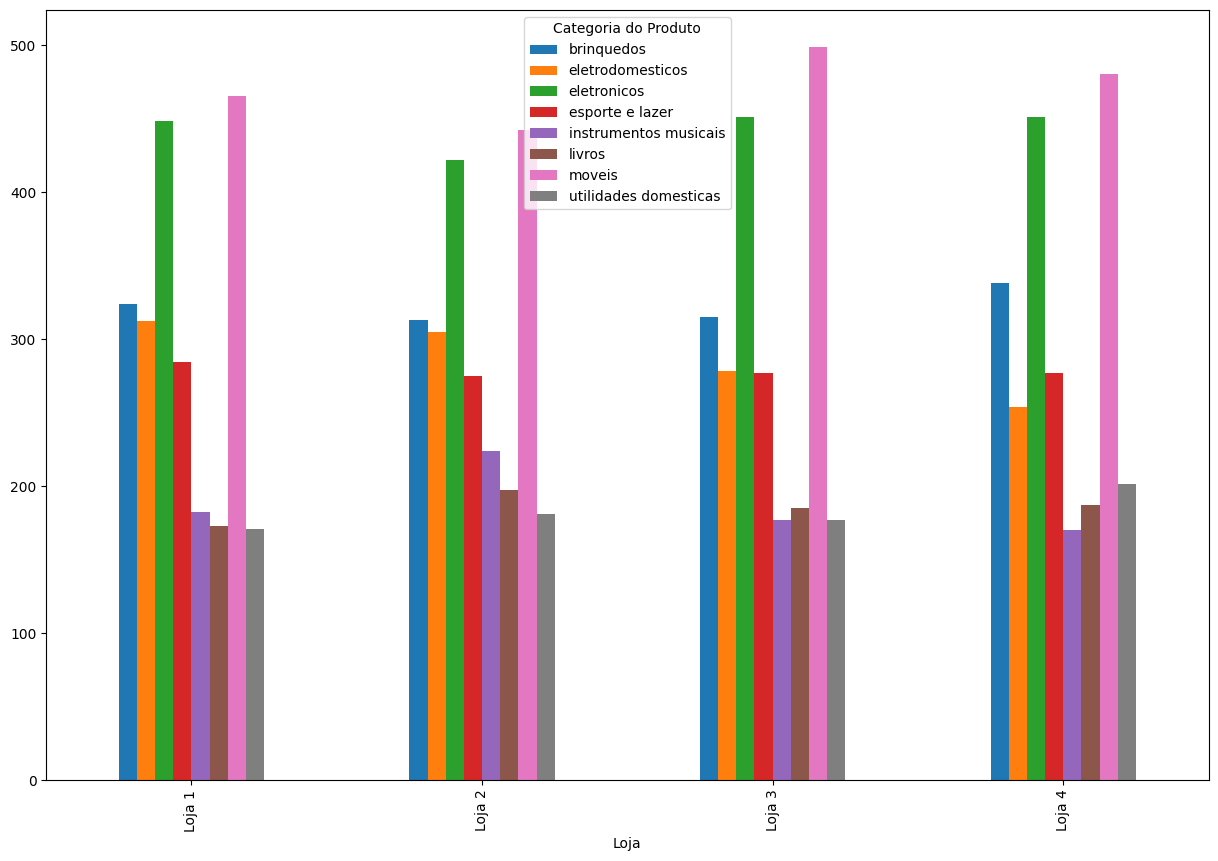

In [ ]:
vendas_por_categorias.plot.bar( figsize=(15, 10))

Média avaliação da loja

<Axes: xlabel='Loja'>

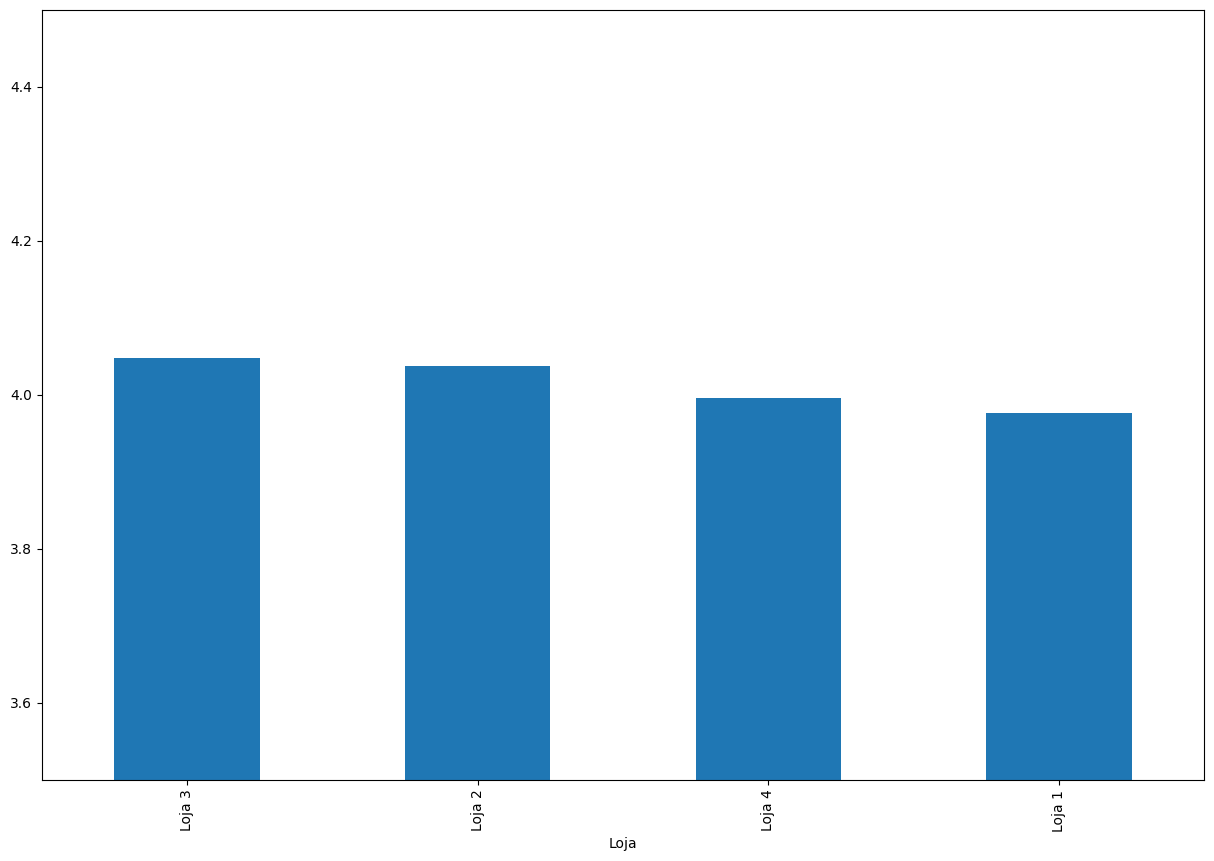

In [ ]:
ax = media_avaliacao.plot.bar()
ax.set_ylim(3.5, 4.5)
media_avaliacao.plot.bar( figsize=(15, 10))

Frete Médio por Loja

<Axes: xlabel='Loja'>

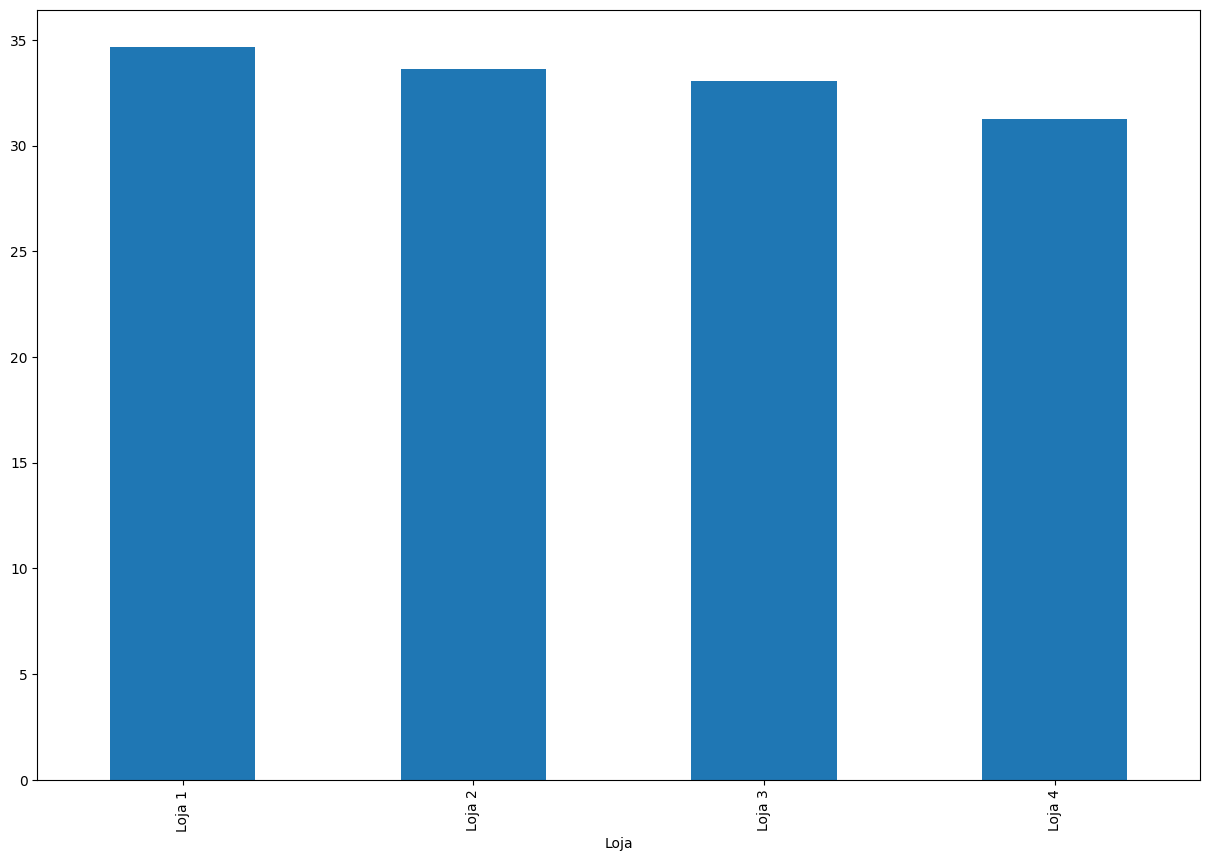

In [ ]:
frete_medio.plot.bar(figsize=(15, 10))

# Relatório Final

Ao analisar os dados processados, conclui-se que é recomendável considerar o encerramento das operações da Loja 4. Entre todas as unidades avaliadas, ela apresenta o menor faturamento total, a menor quantidade de produtos vendidos nas principais categorias e, além disso, figura como a segunda pior avaliada em termos de satisfação.

Esses indicadores, em conjunto, demonstram um desempenho inferior consistente, o que pode comprometer a eficiência e a rentabilidade geral da operação.